In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss
)

from imblearn.over_sampling import SMOTE

import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [28]:
df = pd.read_csv(
    "../data/processed/creditcard_processed.csv"
)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [29]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training data: (226980, 30)
Test data: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [31]:
X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model training data:", X_train_model.shape)
print("Calibration data:", X_calib.shape)
print("Final test data:", X_test.shape)

Model training data: (181584, 30)
Calibration data: (45396, 30)
Final test data: (56746, 30)


In [32]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample( # type: ignore
    X_train_model,
    y_train_model
)

print("Before SMOTE:")
print(y_train_model.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    181282
1       302
Name: count, dtype: int64

After SMOTE:
Class
0    181282
1    181282
Name: count, dtype: int64


In [33]:
smote_model = joblib.load(
    "../models/smote_model.pkl"
)

print("SMOTE model loaded successfully.")

SMOTE model loaded successfully.


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

calibration_smote_model = GradientBoostingClassifier(
    random_state=42
)

print("Training SMOTE model for calibration...")

calibration_smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("Calibration model training completed!")

Training SMOTE model for calibration...
Calibration model training completed!


In [35]:
y_prob_before = calibration_smote_model.predict_proba(
    X_calib
)[:, 1]

print("First 10 probabilities:")
print(y_prob_before[:10])

First 10 probabilities:
[0.00168748 0.00346837 0.0032119  0.00253361 0.00375821 0.00285323
 0.00101931 0.00144699 0.00087753 0.35054216]


In [36]:
pr_auc_before = average_precision_score(
    y_calib,
    y_prob_before
)

print(f"PR-AUC before calibration: {pr_auc_before:.4f}")

PR-AUC before calibration: 0.8105


In [37]:
brier_before = brier_score_loss(
    y_calib,
    y_prob_before
)

print(f"Brier score before calibration: {brier_before:.6f}")

Brier score before calibration: 0.005139


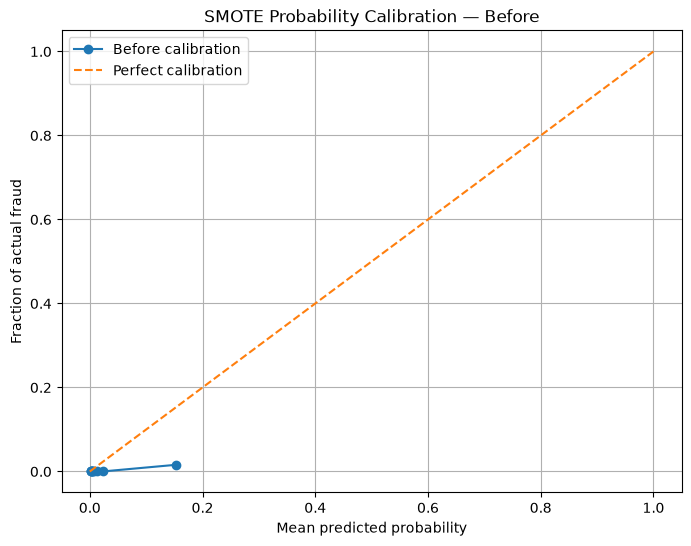

In [38]:
prob_true_before, prob_pred_before = calibration_curve(
    y_calib,
    y_prob_before,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual fraud")
plt.title("SMOTE Probability Calibration — Before")

plt.legend()
plt.grid()

plt.show()

In [50]:
import sklearn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [52]:
from sklearn.calibration import CalibratedClassifierCV
import inspect

print(inspect.signature(CalibratedClassifierCV))

(estimator=None, *, method='sigmoid', cv=None, n_jobs=None, ensemble='auto')


In [53]:
calibrated_model = CalibratedClassifierCV(
    FrozenEstimator(calibration_smote_model),
    method="sigmoid"
)

print("Calibrated model created.")

Calibrated model created.


In [54]:
print("Fitting probability calibrator...")

calibrated_model.fit(
    X_calib,
    y_calib
)

print("Calibration completed!")

Fitting probability calibrator...
Calibration completed!


In [55]:
y_prob_after = calibrated_model.predict_proba(
    X_calib
)[:, 1]

print("First 10 calibrated probabilities:")
print(y_prob_after[:10])

First 10 calibrated probabilities:
[1.51659920e-05 3.12961804e-05 2.89677232e-05 2.28182473e-05
 3.39296908e-05 2.57143989e-05 9.14068095e-06 1.29953841e-05
 7.86449268e-06 4.90519416e-03]


In [56]:
brier_after = brier_score_loss(
    y_calib,
    y_prob_after
)

print("Brier score comparison")
print("-----------------------")
print(f"Before calibration: {brier_before:.6f}")
print(f"After calibration:  {brier_after:.6f}")

Brier score comparison
-----------------------
Before calibration: 0.005139
After calibration:  0.000467


In [57]:
prob_true_after, prob_pred_after = calibration_curve(
    y_calib,
    y_prob_after,
    n_bins=10,
    strategy="quantile"
)

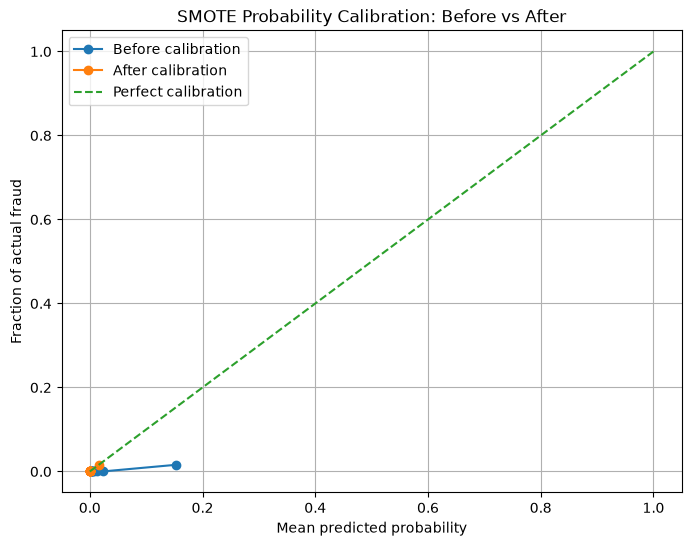

In [58]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before calibration"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="After calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual fraud")

plt.title("SMOTE Probability Calibration: Before vs After")

plt.legend()
plt.grid()

plt.show()

In [59]:
pr_auc_after = average_precision_score(
    y_calib,
    y_prob_after
)

print("PR-AUC comparison")
print("------------------")
print(f"Before calibration: {pr_auc_before:.4f}")
print(f"After calibration:  {pr_auc_after:.4f}")

PR-AUC comparison
------------------
Before calibration: 0.8105
After calibration:  0.8105


In [60]:
calibration_results = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "PR-AUC"
    ],
    "Before Calibration": [
        brier_before,
        pr_auc_before
    ],
    "After Calibration": [
        brier_after,
        pr_auc_after
    ]
})

calibration_results

,Metric,Before Calibration,After Calibration
0,Brier Score,0.005139,0.000467
1,PR-AUC,0.810514,0.810514


In [61]:
y_test_prob_calibrated = calibrated_model.predict_proba(
    X_test
)[:, 1]

print("First 10 calibrated test probabilities:")
print(y_test_prob_calibrated[:10])

First 10 calibrated test probabilities:
[1.51663722e-04 1.63495730e-05 1.60874317e-04 2.57843151e-05
 1.24859779e-03 3.63699941e-05 1.80407403e-05 1.91783029e-05
 2.33153564e-04 1.60019084e-05]


In [62]:
test_pr_auc = average_precision_score(
    y_test,
    y_test_prob_calibrated
)

print(f"Test PR-AUC: {test_pr_auc:.6f}")

Test PR-AUC: 0.695058


In [63]:
test_brier = brier_score_loss(
    y_test,
    y_test_prob_calibrated
)

print(f"Test Brier Score: {test_brier:.6f}")

Test Brier Score: 0.000617


In [64]:
test_threshold = 0.5

y_test_pred = (
    y_test_prob_calibrated >= test_threshold
).astype(int)

print("Test predictions created.")

Test predictions created.


In [66]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Precision: 0.8718
Recall:    0.7158
F1-score:  0.7861


In [67]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

print("Confusion Matrix")
print("-----------------")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Confusion Matrix
-----------------
True Negatives : 56641
False Positives: 10
False Negatives: 27
True Positives : 68


In [68]:
final_calibration_results = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Test Result": [
        test_brier,
        test_pr_auc,
        test_precision,
        test_recall,
        test_f1
    ]
})

final_calibration_results

,Metric,Test Result
0,Brier Score,0.000617
1,PR-AUC,0.695058
2,Precision,0.871795
3,Recall,0.715789
4,F1-score,0.786127


In [49]:
joblib.dump(
    calibrated_model,
    "../models/calibrated_smote_model.pkl"
)

print("Calibrated SMOTE model saved successfully.")

Calibrated SMOTE model saved successfully.
